In [ ]:
from google.colab import files

uploaded = files.upload()

Saving standardized_384.zip to standardized_384.zip


In [ ]:
import zipfile

zip_path = "/content/standardized_384.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Extraction complete!")

Extraction complete!


In [ ]:
import os

for item in os.listdir('/content'):
    print(item)

.config
__MACOSX
standardized_384.zip
standardized_384
sample_data


In [ ]:
import os

dataset_path = "/content/standardized_384"

print(os.listdir(dataset_path))

['trash', 'cardboard', 'plastic', 'glass', 'battery', 'biological', 'metal', 'shoes', '.DS_Store', 'paper', 'clothes']


In [ ]:
import os

import os

dataset_path = "/content/standardized_384"

classes = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Number of Classes:", len(classes))
print()

for c in sorted(classes):
    count = len(os.listdir(os.path.join(dataset_path, c)))
    print(f"{c}: {count}")

Number of Classes: 10

battery: 756
biological: 699
cardboard: 1411
clothes: 1892
glass: 1736
metal: 930
paper: 1336
plastic: 1597
shoes: 1449
trash: 453


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50

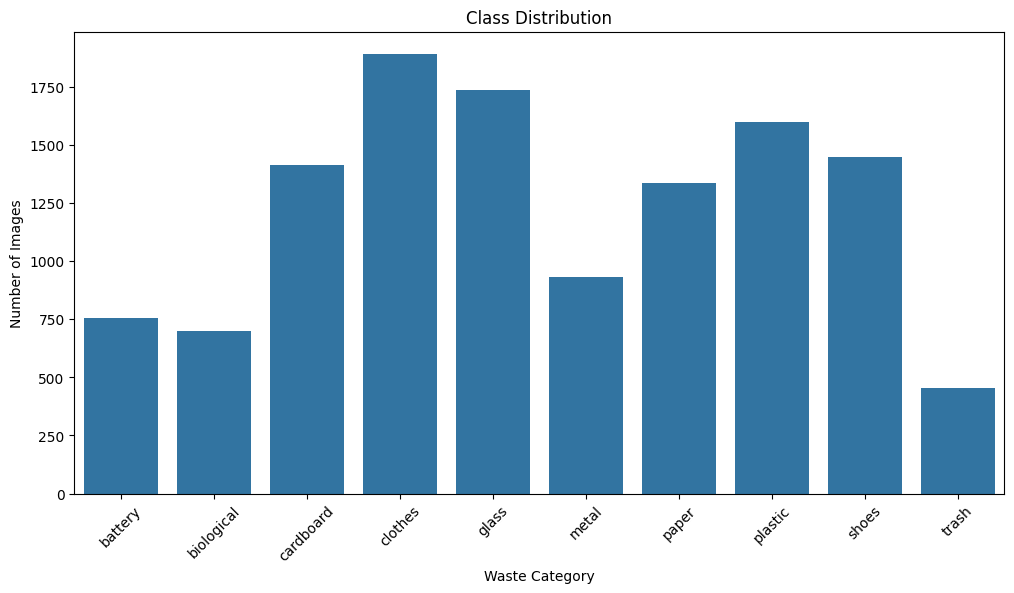

In [ ]:
counts = []

for c in sorted(classes):
    counts.append(
        len(os.listdir(os.path.join(dataset_path, c)))
    )

plt.figure(figsize=(12,6))

sns.barplot(
    x=sorted(classes),
    y=counts
)

plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")

plt.savefig("class_distribution.png")

plt.show()

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 9811 images belonging to 10 classes.


In [ ]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2448 images belonging to 10 classes.


In [ ]:
num_classes = len(classes)

cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        num_classes,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1299s 4s/step - accuracy: 0.2856 - loss: 2.0407 - val_accuracy: 0.4285 - val_loss: 1.6420
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1314s 4s/step - accuracy: 0.4260 - loss: 1.6582 - val_accuracy: 0.5196 - val_loss: 1.4159
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1262s 4s/step - accuracy: 0.4745 - loss: 1.5390 - val_accuracy: 0.5151 - val_loss: 1.4147
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1255s 4s/step - accuracy: 0.5086 - loss: 1.4492 - val_accuracy: 0.5629 - val_loss: 1.2808
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1321s 4s/step - accuracy: 0.5285 - loss: 1.3811 - val_accuracy: 0.5727 - val_loss: 1.2418
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1243s 4s/step - accuracy: 0.5390 - loss: 1.3413 - val_accuracy: 0.5637 - val_loss: 1.2865
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1251s 4s/step - accuracy: 0.5632 - loss: 1.2971 - val_accuracy: 0.6140 - val_loss: 1.1680
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1252s 4s/step - accuracy: 0.5765 - loss: 1.2554 - 

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

predictions = Dense(
    num_classes,
    activation='softmax'
)(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [ ]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_mobile = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 633s 2s/step - accuracy: 0.7686 - loss: 0.7172 - val_accuracy: 0.8607 - val_loss: 0.4481
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 642s 2s/step - accuracy: 0.8586 - loss: 0.4226 - val_accuracy: 0.8697 - val_loss: 0.4004
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 634s 2s/step - accuracy: 0.8836 - loss: 0.3524 - val_accuracy: 0.8725 - val_loss: 0.3817
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 629s 2s/step - accuracy: 0.8943 - loss: 0.3200 - val_accuracy: 0.8709 - val_loss: 0.3886
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 624s 2s/step - accuracy: 0.9008 - loss: 0.2978 - val_accuracy: 0.8922 - val_loss: 0.3534
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 626s 2s/step - accuracy: 0.9050 - loss: 0.2825 - val_accuracy: 0.8922 - val_loss: 0.3484
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 633s 2s/step - accuracy: 0.9159 - loss: 0.2529 - val_accuracy: 0.8893 - val_loss: 0.3528
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 622s 2s/step - accuracy: 0.9125 - loss: 0.2506 - val_accu

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = GlobalAveragePooling2D()(
    base_model.output
)

output = Dense(
    num_classes,
    activation='softmax'
)(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [1]:
history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

NameError: name 'resnet_model' is not defined

In [2]:
cnn_acc = max(
    history_cnn.history['val_accuracy']
)

mobile_acc = max(
    history_mobile.history['val_accuracy']
)

resnet_acc = max(
    history_resnet.history['val_accuracy']
)

results = pd.DataFrame({

    "Model":[
        "Custom CNN",
        "MobileNetV2",
        "ResNet50"
    ],

    "Validation Accuracy":[
        cnn_acc,
        mobile_acc,
        resnet_acc
    ]
})

results

NameError: name 'history_cnn' is not defined

In [3]:
plt.figure(figsize=(8,5))

plt.plot(history_mobile.history['loss'])
plt.plot(history_mobile.history['val_loss'])

plt.title("MobileNetV2 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.savefig("mobilenet_loss.png")

plt.show()

NameError: name 'plt' is not defined

In [4]:
predictions = mobilenet_model.predict(val_data)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = val_data.classes

NameError: name 'mobilenet_model' is not defined

In [5]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

NameError: name 'confusion_matrix' is not defined

In [6]:
class_names = list(
    val_data.class_indices.keys()
)

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

NameError: name 'val_data' is not defined

In [7]:
cnn_acc = max(
    history_cnn.history['val_accuracy']
)

mobile_acc = max(
    history_mobile.history['val_accuracy']
)

resnet_acc = max(
    history_resnet.history['val_accuracy']
)

results = pd.DataFrame({

    "Model":[
        "Custom CNN",
        "MobileNetV2",
        "ResNet50"
    ],

    "Validation Accuracy":[
        cnn_acc,
        mobile_acc,
        resnet_acc
    ]
})

results

NameError: name 'history_cnn' is not defined

In [8]:
cnn_model.save("custom_cnn.h5")

mobilenet_model.save("mobilenetv2_model.h5")

resnet_model.save("resnet50_model.h5")

NameError: name 'cnn_model' is not defined